# 1. Import and Hardware Setup

In [42]:
import torch
import torch.optim as optim
import torch.nn as nn

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

import matplotlib.pyplot as plt

!pip install tqdm ipywidgets -q
from tqdm.auto import tqdm

In [43]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

DATA_PATH = './Data'

cuda


# 2. Hyperparameter

In [44]:
IMG_SIZE = 224
IN_CHANNELS = 3
BATCH_SIZE = 128
NUM_CLASSES = 101

EPOCHS = 1
LR = 3e-3

# 3. Data Preparation

In [45]:
stats = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [46]:
# Download dummy data without transforms
dummy_data = datasets.Food101(root=DATA_PATH, split='train', download=True)

# Random split the dummy data and extract the indices
train_size = int(0.8 * len(dummy_data))
val_size = len(dummy_data) - train_size
train_tmp_subset, val_tmp_subset = random_split(dummy_data, [train_size, val_size])

train_indices = train_tmp_subset.indices
val_indices = val_tmp_subset.indices

# Create train and validation subset with correct transform
train_dataset = datasets.Food101(root=DATA_PATH, split='train',
                                 download=False, transform=train_transform)
val_dataset = datasets.Food101(root=DATA_PATH, split='train',
                                download=False, transform=test_transform)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

# Download test dataset
test_dataset = datasets.Food101(root=DATA_PATH, split='test',
                                download=True, transform=test_transform)


In [47]:
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, persistent_workers=False)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, persistent_workers=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, persistent_workers=False)

# 4. Network Architecture

![MobileNet](figures/MobileNetV1.png)

In [ ]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride, alpha=1.0):
        super().__init__()
        in_channels = int(in_channels * alpha)
        out_channels = int(out_channels * alpha)
        
        # 1. Depthwise Convolution: filter each channel seperately
        self.depthwise = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=stride,
                      padding=1, groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )
        
        # 2. Pointwise Convolution: combines the Channels via 1x1 Conv
        self.pointwise = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1,
                      padding=0, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x
    
class MobileNetV1(nn.Module):
    def __init__(self, in_channels, num_classes, alpha=1.0):
        super().__init__()
        
        # The first conv
        self.first_conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(int(32 * alpha)),
            nn.ReLU(inplace=True)
        )
        
        # Layers structure
        self.layers = nn.Sequential(
            DepthwiseSeparableConv(32, 64, 1, alpha),
            DepthwiseSeparableConv(64, 128, 2, alpha),
            DepthwiseSeparableConv(128, 128, 1, alpha),
            DepthwiseSeparableConv(128, 256, 2, alpha),
            DepthwiseSeparableConv(256, 256, 1, alpha),
            DepthwiseSeparableConv(256, 512, 2, alpha),
            *[DepthwiseSeparableConv(512, 512, 1, alpha) for _ in range(5)], # 5 identical layers
            DepthwiseSeparableConv(512, 1024, 2, alpha),
            DepthwiseSeparableConv(1024, 1024, 1, alpha)
        )
        
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(int(1024 * alpha), num_classes)
        
    def forward(self, x):
        x = self.first_conv(x)
        x = self.layers(x)
        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [ ]:
model = MobileNetV1(in_channels=IN_CHANNELS, num_classes=NUM_CLASSES).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters())/1e6):.2f}M")

# Use multiple GPUs if available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

Total parameters: 3.31M


# 5. Training Preparation

In [50]:
class EarlyStopping:
    def __init__(self, patience=10, delta=0, save_path='best_checkpoint.pth'):
        self.patience = patience
        self.delta = delta
        self.save_path = save_path
        
        self.early_stop = False
        self.counter = 0
        self.verbose = False
        self.best_loss = None
        
    def __call__(self, val_loss, model):
        # 1. For the first epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            
        # 2. If the loss didnt reduce as expect
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter > self.patience:
                self.early_stop = True

        # 3. The loss reduced properly
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print('Saving best checkpoint ...')
        state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(state_dict, self.save_path)

In [51]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    div_factor=10,
    final_div_factor=100
)

scaler = torch.amp.GradScaler(device=device)

In [52]:
def train(model, loader, criterion, optimizer, scaler, scheduler):
    model.train()
    loop = tqdm(loader, desc='Training', leave=False)
    train_loss, train_acc = 0, 0
    
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        # Get prediction and loss using Mixed Precision
        with torch.amp.autocast(device_type=device.type):
            out = model(x)
            loss = criterion(out, y)
            
        # Scale up the loss and backpropagate
        scaler.scale(loss).backward()
        
        # Scale down the gradient and clip it
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # 
        scaler.step(optimizer)
        
        # Update the scale factor and scheduler (OneCycleLR needs per-batch step)
        scaler.update()
        scheduler.step()
        
        train_loss += loss.detach() * x.size(0)
        train_acc += (out.argmax(1) == y).sum()
        
    return train_loss.item() / len(loader.dataset), train_acc.item() / len(loader.dataset)

def validate(model, loader, criterion):
    model.eval()
    val_loss = 0
    loop = tqdm(loader, desc='Validation', leave=False)
    
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            out = model(x)
            loss = criterion(out, y)
        val_loss += loss.detach() * x.size(0)
    return val_loss.item() / len(loader.dataset)

def test(model, loader):
    model.eval()
    test_acc = 0
    loop = tqdm(loader, desc='Testing', leave=False)
    
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            out = model(x)
        test_acc += (out.argmax(1) == y).sum()
    return test_acc.item() / len(loader.dataset)

# 6. Train

In [53]:
train_losses, val_losses = [], []
train_accuracies, test_accuracies = [], []
early_stopping = EarlyStopping(patience=10)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scaler, scheduler)
    val_loss = validate(model, val_loader, criterion)
    test_acc = test(model, test_loader)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: train_loss: {train_loss:.2f}, val_loss: {val_loss:.2f}, " +
          f"train_acc: {train_acc:.2f}, test_acc: {test_acc:.2f}")
    
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early Stopping")
        break

Training:   0%|          | 0/474 [00:00<?, ?it/s]

/tmp/ipykernel_5723/2834042840.py:27: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Testing:   0%|          | 0/198 [00:00<?, ?it/s]

Epoch 1/1: train_loss: 4.53, val_loss: 4.39, train_acc: 0.02, test_acc: 0.04


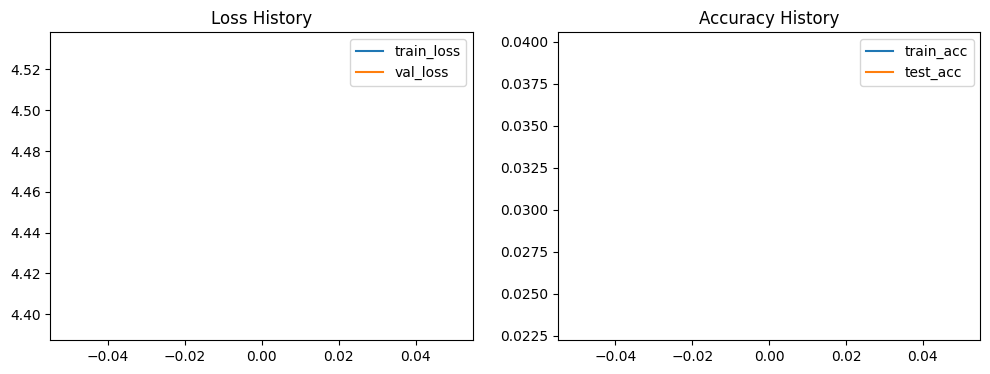

In [54]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label= 'train_loss')
plt.plot(val_losses, label = 'val_loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label = 'train_acc')
plt.plot(test_accuracies, label = 'test_acc')
plt.title('Accuracy History')
plt.legend()

# 7. GradCAM

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 4.8 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 4.8 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (pyproject.toml) ... done


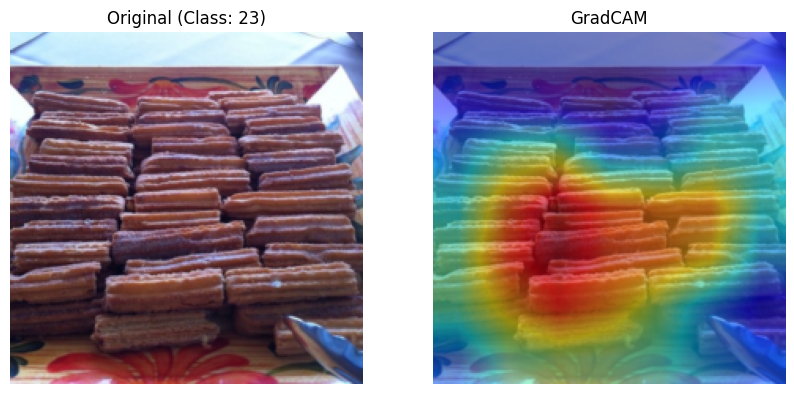

In [ ]:
!pip install grad-cam -q

import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Letzte Convolutional Layer von MobileNet als Target
target_layers = [model.layers[-1]]

# GradCAM Instanz erstellen
cam = GradCAM(model=model, target_layers=target_layers)

# Ein Bild aus dem Test-Loader holen
model.eval()
data_iter = iter(test_loader)
images, labels = next(data_iter)

# Nur das erste Bild des Batches verwenden
input_tensor = images[0:1].to(device)
label = labels[0].item()

# Forward pass für GradCAM
grayscale_cam = cam(input_tensor=input_tensor)
grayscale_cam = grayscale_cam[0, :]

# Originalbild für die Visualisierung ent-normalisieren
img = images[0].numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = std * img + mean
img = np.clip(img, 0, 1)

# Heatmap über das Bild legen
visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

# Visualisieren
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title(f"Original (Class: {label})")
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("GradCAM")
plt.imshow(visualization)
plt.axis('off')

plt.show()